In [1]:
# ==========================================================
# STEP 1 : Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("✅ All Libraries Imported Successfully")
print("TensorFlow Version :", tf.__version__)


✅ All Libraries Imported Successfully
TensorFlow Version : 2.21.0


In [2]:
# ==========================================================
# STEP 2 : Load Dataset
# ==========================================================

df = pd.read_excel("../Data/processed_fraud_dataset.xlsx")

print("✅ Dataset Loaded Successfully")
print("Dataset Shape :", df.shape)

df.head()

✅ Dataset Loaded Successfully
Dataset Shape : (10000, 16)


,Transaction_ID,Customer_ID,Age,Gender,Product_Category,Amount,Payment_Method,Device,Browser,Country,IP_Address,Shipping_Address_Match,Is_Fraud,Transaction_Hour,Transaction_Day,Transaction_Month
0,0,756,42,1,1,28633.39,0,2,1,4,185,0,0,23,13,1
1,1,948,46,0,2,15707.87,0,0,0,1,4498,1,0,11,26,7
2,2,2464,22,1,4,29847.79,1,1,0,1,7829,1,0,4,19,6
3,3,185,69,1,6,6357.38,4,2,0,1,9566,0,1,12,8,5
4,4,75,37,0,2,44753.01,3,1,0,5,2685,0,0,14,27,11


In [3]:
# ==========================================================
# STEP 3 : Dataset Information
# ==========================================================

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction_ID          10000 non-null  int64  
 1   Customer_ID             10000 non-null  int64  
 2   Age                     10000 non-null  int64  
 3   Gender                  10000 non-null  int64  
 4   Product_Category        10000 non-null  int64  
 5   Amount                  10000 non-null  float64
 6   Payment_Method          10000 non-null  int64  
 7   Device                  10000 non-null  int64  
 8   Browser                 10000 non-null  int64  
 9   Country                 10000 non-null  int64  
 10  IP_Address              10000 non-null  int64  
 11  Shipping_Address_Match  10000 non-null  int64  
 12  Is_Fraud                10000 non-null  int64  
 13  Transaction_Hour        10000 non-null  int64  
 14  Transaction_Day         10000 non-null  int64  
 1

In [4]:
# ==========================================================
# STEP 4 : Statistical Summary
# ==========================================================

df.describe()

,Transaction_ID,Customer_ID,Age,Gender,Product_Category,Amount,Payment_Method,Device,Browser,Country,IP_Address,Shipping_Address_Match,Is_Fraud,Transaction_Hour,Transaction_Day,Transaction_Month
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,1444.824000,43.996400,0.49770,3.00560,24913.410187,2.515100,0.994600,1.527700,2.998800,4999.50000,0.504600,0.123400,11.335900,15.554500,6.545800
std,2886.89568,832.284361,15.345004,0.50002,1.99318,14370.491926,1.701606,0.815376,1.119445,1.994241,2886.89568,0.500004,0.328912,6.941807,8.785747,3.464174
min,0.00000,0.000000,18.000000,0.00000,0.00000,102.950000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2499.75000,725.750000,31.000000,0.00000,1.00000,12242.850000,1.000000,0.000000,1.000000,1.000000,2499.75000,0.000000,0.000000,5.000000,8.000000,4.000000
50%,4999.50000,1435.000000,44.000000,0.00000,3.00000,25242.260000,3.000000,1.000000,2.000000,3.000000,4999.50000,1.000000,0.000000,11.000000,15.000000,7.000000
75%,7499.25000,2174.250000,57.000000,1.00000,5.00000,37250.005000,4.000000,2.000000,3.000000,5.000000,7499.25000,1.000000,0.000000,17.000000,23.000000,10.000000
max,9999.00000,2894.000000,70.000000,1.00000,6.00000,49986.120000,5.000000,2.000000,3.000000,6.000000,9999.00000,1.000000,1.000000,23.000000,31.000000,12.000000


Is_Fraud
0    8766
1    1234
Name: count, dtype: int64


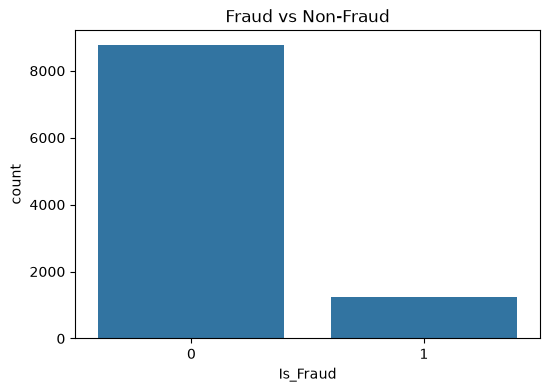

In [5]:
# ==========================================================
# STEP 6 : Target Distribution
# ==========================================================

print(df["Is_Fraud"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Is_Fraud")

plt.title("Fraud vs Non-Fraud")

plt.show()

In [6]:
# ==========================================================
# STEP 7 : Features & Target
# ==========================================================

X = df.drop("Is_Fraud", axis=1)

y = df["Is_Fraud"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (10000, 15)
Target Shape : (10000,)


In [7]:
# ==========================================================
# STEP 8 : Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (8000, 15)
Testing Shape : (2000, 15)


In [8]:
# ==========================================================
# STEP 9 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [9]:
# ==========================================================
# STEP 10 : Store Model Results
# ==========================================================

results = []

print("Results List Created Successfully")

Results List Created Successfully


In [10]:
# ==========================================================
# STEP 11 : Logistic Regression
# ==========================================================

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)

results.append([
    "Logistic Regression",
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred)
])

print("Logistic Regression Accuracy :", lr_acc)

Logistic Regression Accuracy : 0.8765


In [11]:
# ==========================================================
# STEP 12 : Decision Tree
# ==========================================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

results.append([
    "Decision Tree",
    accuracy_score(y_test, dt_pred),
    precision_score(y_test, dt_pred),
    recall_score(y_test, dt_pred),
    f1_score(y_test, dt_pred)
])

print("Decision Tree Accuracy :", dt_acc)

Decision Tree Accuracy : 0.7715


In [12]:
# ==========================================================
# STEP 13 : Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

results.append([
    "Random Forest",
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
])

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.8765


In [13]:
# ==========================================================
# STEP 14 : K-Nearest Neighbors
# ==========================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)

results.append([
    "KNN",
    accuracy_score(y_test, knn_pred),
    precision_score(y_test, knn_pred),
    recall_score(y_test, knn_pred),
    f1_score(y_test, knn_pred)
])

print("KNN Accuracy :", knn_acc)

KNN Accuracy : 0.865


In [14]:
# ==========================================================
# STEP 15 : Naive Bayes
# ==========================================================

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

nb_acc = accuracy_score(y_test, nb_pred)

results.append([
    "Naive Bayes",
    accuracy_score(y_test, nb_pred),
    precision_score(y_test, nb_pred),
    recall_score(y_test, nb_pred),
    f1_score(y_test, nb_pred)
])

print("Naive Bayes Accuracy :", nb_acc)

Naive Bayes Accuracy : 0.8765


In [15]:
# ==========================================================
# STEP 16 : Model Comparison
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8765,0.000000,0.000000,0.000000
2,Random Forest,0.8765,0.000000,0.000000,0.000000
4,Naive Bayes,0.8765,0.000000,0.000000,0.000000
3,KNN,0.8650,0.171429,0.024291,0.042553
1,Decision Tree,0.7715,0.142857,0.170040,0.155268


In [16]:
# ==========================================================
# STEP 16 : Model Comparison
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8765,0.000000,0.000000,0.000000
2,Random Forest,0.8765,0.000000,0.000000,0.000000
4,Naive Bayes,0.8765,0.000000,0.000000,0.000000
3,KNN,0.8650,0.171429,0.024291,0.042553
1,Decision Tree,0.7715,0.142857,0.170040,0.155268


In [17]:
# ==========================================================
# STEP 17 : Build Artificial Neural Network (ANN)
# ==========================================================

class FraudANN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = Dense(64, activation="relu")
        self.dense2 = Dense(32, activation="relu")
        self.dense3 = Dense(16, activation="relu")
        self.output_layer = Dense(1, activation="sigmoid")

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

ann_model = FraudANN()

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "fraud_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ==========================================================
# STEP 18 : Train ANN
# ==========================================================

history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8759 - loss: 0.3954 - val_accuracy: 0.8775 - val_loss: 0.3798
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8764 - loss: 0.3738 - val_accuracy: 0.8775 - val_loss: 0.3787
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3705 - val_accuracy: 0.8775 - val_loss: 0.3789
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8764 - loss: 0.3676 - val_accuracy: 0.8775 - val_loss: 0.3809
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8764 - loss: 0.3637 - val_accuracy: 0.8775 - val_loss: 0.3824
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8764 - loss: 0.3604 - val_accuracy: 0.8775 - val_loss: 0.3817
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8764 - loss: 0.3575 - val_accuracy: 0.8775 - val_loss: 0.3837
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8766 - loss: 0.3529 - val_accuracy: 0.

In [19]:
# ==========================================================
# STEP 19 : Evaluate ANN
# ==========================================================

loss, accuracy = ann_model.evaluate(X_test_scaled, y_test)

print("ANN Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8640 - loss: 0.4313
ANN Accuracy : 0.8640000224113464


In [8]:
# ==========================================================
# STEP 20 : ANN Prediction
# ==========================================================

ann_prob = ann_model.predict(X_test_scaled)

ann_pred = (ann_prob > 0.5).astype(int)

NameError: name 'ann_model' is not defined

In [21]:
# ==========================================================
# STEP 21 : ANN Metrics
# ==========================================================

ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)

results.append([
    "Artificial Neural Network",
    ann_accuracy,
    ann_precision,
    ann_recall,
    ann_f1
])

print("Accuracy :", ann_accuracy)
print("Precision :", ann_precision)
print("Recall :", ann_recall)
print("F1 Score :", ann_f1)

Accuracy : 0.864
Precision : 0.1794871794871795
Recall : 0.02834008097165992
F1 Score : 0.04895104895104895


In [22]:
# ==========================================================
# STEP 22 : Final Model Comparison
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8765,0.000000,0.000000,0.000000
2,Random Forest,0.8765,0.000000,0.000000,0.000000
4,Naive Bayes,0.8765,0.000000,0.000000,0.000000
3,KNN,0.8650,0.171429,0.024291,0.042553
5,Artificial Neural Network,0.8640,0.179487,0.028340,0.048951
1,Decision Tree,0.7715,0.142857,0.170040,0.155268


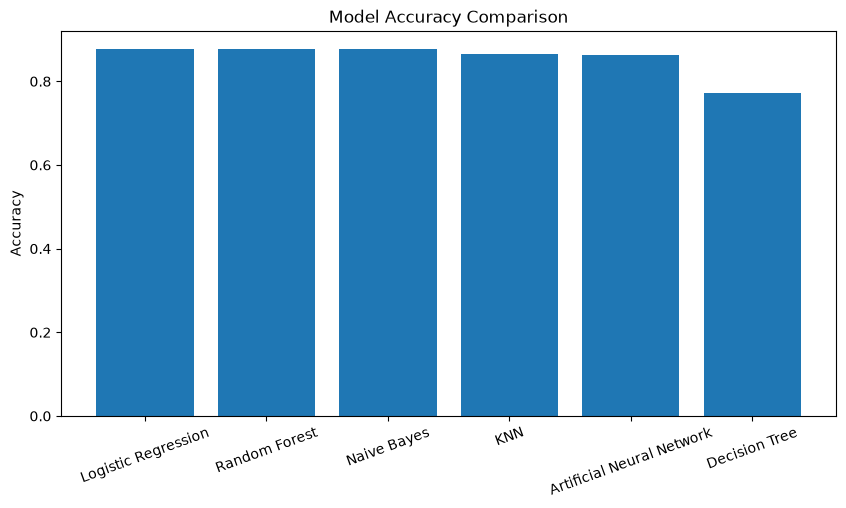

In [23]:
# ==========================================================
# STEP 23 : Accuracy Comparison
# ==========================================================

plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [24]:
# ==========================================================
# STEP 24 : Save Models
# ==========================================================

joblib.dump(rf_model, "../models/best_fraud_model.pkl")

ann_model.save("../models/ann_fraud_model.keras")

print("Models Saved Successfully")

Models Saved Successfully


In [25]:
# ==========================================================
# STEP 25 : Best Model
# ==========================================================

print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

print("\nBest Model :")

print(results_df.iloc[0])

FINAL MODEL COMPARISON
                       Model  Accuracy  Precision    Recall  F1 Score
0        Logistic Regression    0.8765   0.000000  0.000000  0.000000
2              Random Forest    0.8765   0.000000  0.000000  0.000000
4                Naive Bayes    0.8765   0.000000  0.000000  0.000000
3                        KNN    0.8650   0.171429  0.024291  0.042553
5  Artificial Neural Network    0.8640   0.179487  0.028340  0.048951
1              Decision Tree    0.7715   0.142857  0.170040  0.155268

Best Model :
Model        Logistic Regression
Accuracy                  0.8765
Precision                    0.0
Recall                       0.0
F1 Score                     0.0
Name: 0, dtype: object


In [31]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

print("✅ Scaler Saved Successfully!")

✅ Scaler Saved Successfully!


In [26]:
import tensorflow as tf

print(tf.__version__)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Working Successfully")

2.21.0
TensorFlow Working Successfully


In [27]:
import sklearn
print("Scikit-learn :", sklearn.__version__)

import matplotlib
print("Matplotlib :", matplotlib.__version__)

import seaborn
print("Seaborn :", seaborn.__version__)

import tensorflow as tf
print("TensorFlow :", tf.__version__)

Scikit-learn : 1.9.0
Matplotlib : 3.11.1
Seaborn : 0.13.2
TensorFlow : 2.21.0


In [28]:
# ==========================================================
# Personalized E-Commerce Fraud Prevention System
# Machine Learning + Deep Learning
# ==========================================================

print("=" * 65)
print("PERSONALIZED E-COMMERCE FRAUD PREVENTION SYSTEM")
print("Machine Learning + Deep Learning")
print("=" * 65)

PERSONALIZED E-COMMERCE FRAUD PREVENTION SYSTEM
Machine Learning + Deep Learning
